**מטלה בלמידת מכונה – ניתוח טקסט (NLP): סיווג חדשות מזויפות**

**שמות הסטודנטים:**  
זוהר אברמוביץ (4156)  
שרון אלימלך (8514)
שרון אלימלך (8514)


בפרויקט זה אנו עוסקים בבעיית סיווג טקסט בינארית, שמטרתה לקבוע האם כתבת חדשות שייכת למחלקה 0 או למחלקה 1.  
ה-dataset שנבחר הוא **Fake News Classification** מ-Kaggle, והוא כולל את הקבצים `train.csv`, `test.csv` ו-`evaluation.csv`, כאשר תהליך האימון והבדיקה המרכזי יתבצע על `train` ו-`test` בהתאם לדרישות המטלה.  
במהלך העבודה נבצע טעינת נתונים, עיבוד מקדים לטקסט, ייצוג הטקסט כמאפיינים מספריים, מימוש עצמאי של האלגוריתם **Multinomial Naive Bayes**, ניסויים עם כמה שיטות Feature Engineering ו-hyperparameters, ולבסוף חיזוי והערכת ביצועים באמצעות מדד **F1**.


**שימוש ב-AI ובמקורות עזר**

להלן דוגמאות לפרומפטים ולעזרים שבהם נעשה שימוש במהלך העבודה:

- "הסבר איך עובד Multinomial Naive Bayes עבור סיווג טקסט, כולל priors, likelihoods ו-Laplace smoothing."  
  **מטרה:** להבין לעומק את האלגוריתם לפני המימוש העצמאי.

- "מה ההבדל בין CountVectorizer לבין TfidfVectorizer, ומתי עדיף להשתמש בכל אחד מהם?"  
  **מטרה:** לבחור שיטות Feature Engineering מתאימות ולהשוות ביניהן.

- "איך מקובל להציג Grid Search עם 5-Fold Cross Validation במחברת של מטלת Machine Learning?"  
  **מטרה:** לוודא שהניסויים והתוצאות יוצגו בצורה ברורה ומסודרת.

נעשה שימוש ב-AI לצורך הבנה, תכנון, ניסוח וסיוע טכני, אך המימוש הותאם לפרויקט, נבדק בפועל, והעבודה מבוססת על הבנה של השלבים והתוצאות.


**Imports and setup**

In this cell we import the libraries used for data handling, text processing, visualization, feature engineering, cross validation, and evaluation.

In [1]:

# %pip install pandas numpy scikit-learn matplotlib jupyter

# Standard libraries for text cleaning
import re
import string
# Libraries for data handling and numerical calculations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn is used for utilities, vectorizers and metrics, not for the Naive Bayes model itself
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

pd.set_option("display.max_colwidth", 120)


**Loading the datasets**

We load the original Kaggle files. The main learning flow uses `train.csv` for training and `test.csv` for final evaluation. `evaluation.csv` is loaded only for inspection.

In [2]:

# Load the three CSV files from the data folder
train = pd.read_csv("data/train.csv", sep=";", index_col=0)
test = pd.read_csv("data/test.csv", sep=";", index_col=0)
evaluation = pd.read_csv("data/evaluation.csv", sep=";", index_col=0)

# Display the first rows to verify that the files were loaded correctly
print("TRAIN HEAD")
display(train.head())

print("TEST HEAD")
display(test.head())

print("EVALUATION HEAD")
display(evaluation.head())


TRAIN HEAD


,title,text,label
0,Palestinians switch off Christmas lights in Bethlehem in anti-Trump protest,"RAMALLAH, West Bank (Reuters) - Palestinians switched off Christmas lights at Jesus traditional birthplace in Bethl...",1
1,China says Trump call with Taiwan president won't change island's status,BEIJING (Reuters) - U.S. President-elect Donald Trump’s call with Taiwan President Tsai Ing-wen was a “petty” move b...,1
2,FAIL! The Trump Organization’s Credit Score Will Make You Laugh,"While the controversy over Trump s personal tax returns continues, business credit rating company Nav decided to tak...",0
3,"Zimbabwe military chief's China trip was normal visit, Beijing says","BEIJING (Reuters) - A trip to Beijing last week by Zimbabwe s military chief was a normal military exchange , China...",1
4,THE MOST UNCOURAGEOUS PRESIDENT EVER Receives A Courage Award…Proceeds To Whine About Current President,There has never been a more UNCOURAGEOUS person in the White House than Barack Obama. He never faced a decision on f...,0


TEST HEAD


,title,text,label
0,"Live from New York, it's a Trump-Clinton rematch - of sorts","NEW YORK (Reuters) - Veteran actor and frequent host Alec Baldwin returned to “Saturday Night Live” on Saturday, deb...",1
1,Catalan separatists to lose majority in tight election: poll,"BARCELONA (Reuters) - Catalonia s independence movement could suffer a serious setback in elections this month, acco...",1
2,North Carolina governor concedes election to Democratic opponent,"WINSTON-SALEM, N.C. (Reuters) - North Carolina Governor Pat McCrory on Monday conceded the state’s contested guberna...",1
3,Draft Senate Iran legislation sets tough new U.S. terms for deal,WASHINGTON (Reuters) - Draft legislation responding to U.S. President Donald Trump’s refusal to certify the Iran nuc...,1
4,California governor taps U.S. Representative Becerra as attorney general,"SACRAMENTO, Calif. (Reuters) - California Governor Jerry Brown on Thursday nominated U.S. Congressman Xavier Becerra...",1


EVALUATION HEAD


,title,text,label
0,"Sanders back in U.S. Senate, blasts 'colonialism' in Puerto Rico",WASHINGTON (Reuters) - Democratic U.S. presidential hopeful Bernie Sanders brought his firebrand rhetoric back to th...,1
1,Kremlin: Syria peoples' congress being 'actively discussed',MOSCOW (Reuters) - A proposal to convene a congress of all Syria s ethnic groups is a joint initiative which is bein...,1
2,Oregon Cop Convicted Of Shattering Biker’s Collarbone With Kick Forgot Dashcam Was On (VIDEO),"In a baffling fit of rage, an Oregon State Police officer has been convicted of ramming his car into a stopped motor...",0
3,Twitter Erupts With Glee Over #CruzSexScandal Rumors (TWEETS),The last thing any politician running for the presidency needs is negative or scandalous hashtags about them trendin...,0
4,MUST WATCH VIDEO: Obama Tries To Trash Trump But Turns Into A Babbling Mess [Video],This is too good to miss! Mr. Teleprompter didn t do so well when he went off script during an appearance in Indiana.,0


**Initial data exploration**

Here we check dataset sizes, column names, label distribution, and missing values. This helps verify that the data is usable before training a model.

Shapes
Train: (24353, 3)
Test: (8117, 3)
Evaluation: (8117, 3)

Columns
Train: ['title', 'text', 'label']
Test: ['title', 'text', 'label']
Evaluation: ['title', 'text', 'label']

Label distribution - train


label
0    11107
1    13246
Name: count, dtype: int64

Label distribution - test


label
0    3753
1    4364
Name: count, dtype: int64

Label distribution - evaluation


label
0    3803
1    4314
Name: count, dtype: int64

Missing values


,train_missing,test_missing,evaluation_missing
title,0,0,0
text,0,0,0
label,0,0,0


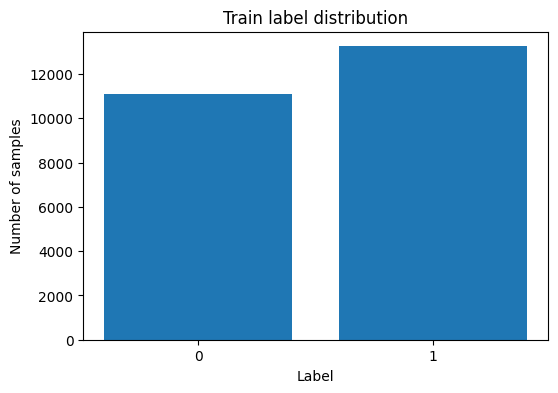

In [3]:

# Check the number of rows and columns in each dataset
print("Shapes")
print("Train:", train.shape)
print("Test:", test.shape)
print("Evaluation:", evaluation.shape)

print("\nColumns")
print("Train:", train.columns.tolist())
print("Test:", test.columns.tolist())
print("Evaluation:", evaluation.columns.tolist())

# Check whether the classes are reasonably balanced
print("\nLabel distribution - train")
display(train["label"].value_counts().sort_index())

print("Label distribution - test")
display(test["label"].value_counts().sort_index())

print("Label distribution - evaluation")
display(evaluation["label"].value_counts().sort_index())

# Make sure there are no missing values before preprocessing
print("Missing values")
display(pd.DataFrame({
    "train_missing": train.isnull().sum(),
    "test_missing": test.isnull().sum(),
    "evaluation_missing": evaluation.isnull().sum()
}))

label_counts = train["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Train label distribution")
plt.xlabel("Label")
plt.ylabel("Number of samples")
plt.show()


**Text preprocessing**

This stage cleans the raw text and creates two text representations: text only, and title combined with text. These cleaned columns will later be used for feature engineering.

In [4]:

# Stopwords are common words that usually add little semantic value
stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    # Convert text to lowercase for consistent processing
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    # Keep only English letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Remove stopwords and rebuild the cleaned sentence
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text.strip()

# Apply the same preprocessing to all datasets
for df in (train, test, evaluation):
    df["content_title_text"] = (df["title"].fillna("") + " " + df["text"].fillna("")).str.strip()
    df["content_text_only"] = df["text"].fillna("").str.strip()

    df["clean_title_text"] = df["content_title_text"].apply(clean_text)
    df["clean_text_only"] = df["content_text_only"].apply(clean_text)


**Preprocessing examples**

We display a few examples before and after cleaning, so it is clear how the preprocessing changes the text.

In [5]:

# This helper displays examples before and after cleaning
def show_preprocessing_examples(df, dataset_name, raw_col, clean_col, n=3):
    examples = df[[raw_col, clean_col, "label"]].head(n).copy()
    examples["length_before"] = examples[raw_col].apply(len)
    examples["length_after"] = examples[clean_col].apply(len)
    print(dataset_name)
    display(examples)

show_preprocessing_examples(train, "TRAIN EXAMPLES", "content_title_text", "clean_title_text", n=3)
show_preprocessing_examples(test, "TEST EXAMPLES", "content_title_text", "clean_title_text", n=3)


TRAIN EXAMPLES


,content_title_text,clean_title_text,label,length_before,length_after
0,"Palestinians switch off Christmas lights in Bethlehem in anti-Trump protest RAMALLAH, West Bank (Reuters) - Palestin...",palestinians switch christmas lights bethlehem anti trump protest ramallah west bank reuters palestinians switched c...,1,1410,1045
1,China says Trump call with Taiwan president won't change island's status BEIJING (Reuters) - U.S. President-elect Do...,china says trump taiwan president won t change island s status beijing reuters u s president elect donald trump s ta...,1,445,340
2,FAIL! The Trump Organization’s Credit Score Will Make You Laugh While the controversy over Trump s personal tax retu...,fail trump organization s credit score make laugh controversy trump s personal tax returns continues business credit...,0,2136,1329


TEST EXAMPLES


,content_title_text,clean_title_text,label,length_before,length_after
0,"Live from New York, it's a Trump-Clinton rematch - of sorts NEW YORK (Reuters) - Veteran actor and frequent host Ale...",live new york s trump clinton rematch sorts new york reuters veteran actor frequent host alec baldwin returned satur...,1,2281,1541
1,Catalan separatists to lose majority in tight election: poll BARCELONA (Reuters) - Catalonia s independence movement...,catalan separatists lose majority tight election poll barcelona reuters catalonia s independence movement suffer set...,1,1342,970
2,"North Carolina governor concedes election to Democratic opponent WINSTON-SALEM, N.C. (Reuters) - North Carolina Gove...",north carolina governor concedes election democratic opponent winston salem n c reuters north carolina governor pat ...,1,2686,1909


**Text length analysis**

We examine the length of the cleaned articles. This gives a basic understanding of the text distribution in the dataset.

Train character count summary


count    24353.000000
mean      1726.284113
std       1413.679437
min          0.000000
25%        930.000000
50%       1522.000000
75%       2136.000000
max      36292.000000
Name: char_count, dtype: float64

Train word count summary


count    24353.000000
mean       236.787542
std        190.391004
min          0.000000
25%        129.000000
50%        211.000000
75%        294.000000
max       4489.000000
Name: word_count, dtype: float64

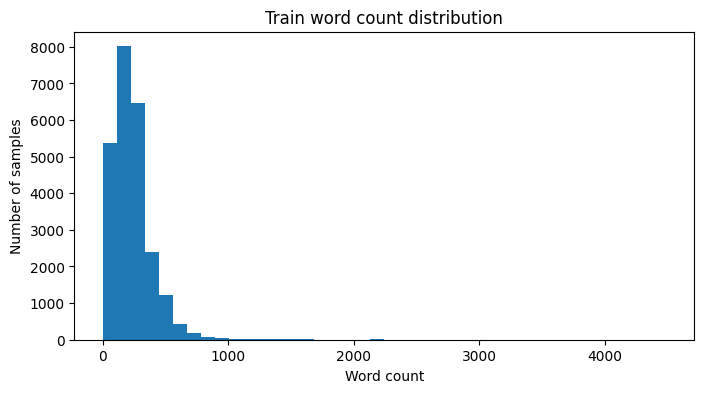

In [6]:

# Add simple length-based statistics for exploratory analysis
for df in (train, test):
    df["char_count"] = df["clean_title_text"].apply(len)
    df["word_count"] = df["clean_title_text"].apply(lambda x: len(x.split()))

print("Train character count summary")
display(train["char_count"].describe())

print("Train word count summary")
display(train["word_count"].describe())

plt.figure(figsize=(8, 4))
plt.hist(train["word_count"], bins=40)
plt.title("Train word count distribution")
plt.xlabel("Word count")
plt.ylabel("Number of samples")
plt.show()


**Feature engineering setup**

Text must be converted into numerical vectors before it can be used by a machine learning algorithm. We compare CountVectorizer, TF-IDF, and TF-IDF with bigrams.

In [7]:

# Create a vectorizer according to the selected feature-engineering configuration
def create_vectorizer(config_name):
    if config_name == "count":
        return CountVectorizer(max_features=5000)
    elif config_name == "tfidf_uni":
        return TfidfVectorizer(max_features=5000)
    elif config_name == "tfidf_bi":
        return TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    else:
        raise ValueError(f"Unknown vectorizer config: {config_name}")

vectorizer_names = ["count", "tfidf_uni", "tfidf_bi"]
text_modes = {
    "text_only": "clean_text_only",
    "title_plus_text": "clean_title_text"
}

print("Vectorizers:", vectorizer_names)
print("Text modes:", list(text_modes.keys()))

# Show how each vectorizer represents a few examples
small_examples = train["clean_title_text"].head(3)

for name in vectorizer_names:
    vec = create_vectorizer(name)
    X_small = vec.fit_transform(small_examples)
    feature_names = vec.get_feature_names_out()[:20]
    print(f"\n{name}")
    print("Shape:", X_small.shape)
    print("First 20 features:", feature_names.tolist())


Vectorizers: ['count', 'tfidf_uni', 'tfidf_bi']
Text modes: ['text_only', 'title_plus_text']

count
Shape: (3, 231)
First 20 features: ['according', 'actually', 'adorned', 'affairs', 'affecting', 'agency', 'alarm', 'anti', 'approach', 'arabs', 'arafat', 'assets', 'august', 'averages', 'bank', 'beginning', 'beijing', 'believe', 'benjamin', 'bethlehem']

tfidf_uni
Shape: (3, 231)
First 20 features: ['according', 'actually', 'adorned', 'affairs', 'affecting', 'agency', 'alarm', 'anti', 'approach', 'arabs', 'arafat', 'assets', 'august', 'averages', 'bank', 'beginning', 'beijing', 'believe', 'benjamin', 'bethlehem']

tfidf_bi
Shape: (3, 549)
First 20 features: ['according', 'according nav', 'actually', 'actually does', 'actually dropped', 'adorned', 'adorned lights', 'affairs', 'affairs office', 'affecting', 'affecting business', 'agency', 'alarm', 'alarm possible', 'anti', 'anti trump', 'approach', 'approach israeli', 'arabs', 'arabs muslims']


**Custom model implementation**

This is our own implementation of Multinomial Naive Bayes. We do not use a ready-made Naive Bayes model from scikit-learn.

In [8]:

# Custom implementation of Multinomial Naive Bayes
class MyMultinomialNaiveBayes(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha=1.0):
        # alpha controls Laplace smoothing
        self.alpha = alpha
        self.classes_ = None
        self.class_log_prior_ = None
        self.feature_log_prob_ = None

    def fit(self, X, y):
        y = np.asarray(y)
        self.classes_ = np.unique(y)

        n_classes = len(self.classes_)
        n_features = X.shape[1]

        self.class_log_prior_ = np.zeros(n_classes)
        self.feature_log_prob_ = np.zeros((n_classes, n_features))

        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]
            class_count = X_c.shape[0]

            # Prior probability of the class: P(class)
            self.class_log_prior_[idx] = np.log(class_count / X.shape[0])

            # Count feature appearances within the current class
            feature_count = np.asarray(X_c.sum(axis=0)).ravel()
            # Laplace smoothing prevents zero probabilities
            smoothed_fc = feature_count + self.alpha
            smoothed_total = smoothed_fc.sum()

            # Store log likelihoods: log(P(feature|class))
            self.feature_log_prob_[idx, :] = np.log(smoothed_fc / smoothed_total)

        return self

    def predict_log_proba(self, X):
        # Combine feature values with learned log likelihoods
        log_probs = X @ self.feature_log_prob_.T
        log_probs = np.asarray(log_probs) + self.class_log_prior_
        return log_probs

    def predict(self, X):
        log_probs = self.predict_log_proba(X)
        # Select the class with the highest log probability
        class_indices = np.argmax(log_probs, axis=1)
        return self.classes_[class_indices]

    def predict_proba(self, X):
        log_probs = self.predict_log_proba(X)
        max_log = np.max(log_probs, axis=1, keepdims=True)
        probs = np.exp(log_probs - max_log)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs


**Baseline model**

We first train a simple baseline using TF-IDF unigrams and alpha=1.0. This gives an initial performance score before running the full experiment grid.

In [9]:

# Baseline uses TF-IDF unigrams as an initial feature representation
baseline_vectorizer = create_vectorizer("tfidf_uni")

X_train_baseline = baseline_vectorizer.fit_transform(train["clean_title_text"])
X_test_baseline = baseline_vectorizer.transform(test["clean_title_text"])

y_train = train["label"].values
y_test = test["label"].values

# Train the custom Naive Bayes model
baseline_model = MyMultinomialNaiveBayes(alpha=1.0)
baseline_model.fit(X_train_baseline, y_train)

baseline_predictions = baseline_model.predict(X_test_baseline)
baseline_probabilities = baseline_model.predict_proba(X_test_baseline)

# F1 is the main evaluation metric for this binary classification task
baseline_f1 = f1_score(y_test, baseline_predictions, average="binary")

print("Baseline F1:", round(baseline_f1, 4))
print("First 5 predictions:")
print(baseline_predictions[:5])


Baseline F1: 0.9292
First 5 predictions:
[0 1 1 1 1]


**Baseline evaluation and flow examples**

Here we evaluate the baseline model and show several test examples with their predictions and predicted probabilities.

In [10]:

print("Baseline classification report")
print(classification_report(y_test, baseline_predictions))

print("Baseline confusion matrix")
# Confusion matrix shows correct and incorrect predictions by class
cm_baseline = confusion_matrix(y_test, baseline_predictions)
display(pd.DataFrame(cm_baseline,
                     index=["Actual 0", "Actual 1"],
                     columns=["Pred 0", "Pred 1"]))

# Show examples that passed through preprocessing, vectorization and prediction
flow_examples = test[["title", "text", "clean_title_text", "label"]].head(3).copy()
flow_examples["prediction"] = baseline_predictions[:3]
flow_examples["prob_class_0"] = baseline_probabilities[:3, 0]
flow_examples["prob_class_1"] = baseline_probabilities[:3, 1]

print("Flow examples")
display(flow_examples)


Baseline classification report
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      3753
           1       0.94      0.92      0.93      4364

    accuracy                           0.92      8117
   macro avg       0.92      0.92      0.92      8117
weighted avg       0.92      0.92      0.92      8117

Baseline confusion matrix


,Pred 0,Pred 1
Actual 0,3474,279
Actual 1,335,4029


Flow examples


,title,text,clean_title_text,label,prediction,prob_class_0,prob_class_1
0,"Live from New York, it's a Trump-Clinton rematch - of sorts","NEW YORK (Reuters) - Veteran actor and frequent host Alec Baldwin returned to “Saturday Night Live” on Saturday, deb...",live new york s trump clinton rematch sorts new york reuters veteran actor frequent host alec baldwin returned satur...,1,0,0.989256,0.010744
1,Catalan separatists to lose majority in tight election: poll,"BARCELONA (Reuters) - Catalonia s independence movement could suffer a serious setback in elections this month, acco...",catalan separatists lose majority tight election poll barcelona reuters catalonia s independence movement suffer set...,1,1,0.001108,0.998892
2,North Carolina governor concedes election to Democratic opponent,"WINSTON-SALEM, N.C. (Reuters) - North Carolina Governor Pat McCrory on Monday conceded the state’s contested guberna...",north carolina governor concedes election democratic opponent winston salem n c reuters north carolina governor pat ...,1,1,0.399521,0.600479


**Grid Search with 5-Fold Cross Validation**

We test all combinations of text representation, vectorizer type, and alpha value. Each combination is evaluated using 5-fold cross validation on the training set.

In [11]:

# Configurations tested in the experiment grid
vectorizer_configs = ["count", "tfidf_uni", "tfidf_bi"]
alpha_values = [0.5, 1.0, 1.5]

# StratifiedKFold keeps the class distribution similar in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y = train["label"].reset_index(drop=True).values
results = []

# Iterate over all combinations of text mode, vectorizer and alpha
for text_mode_name, text_col in text_modes.items():
    X_text = train[text_col].reset_index(drop=True)

    for vec_name in vectorizer_configs:
        for alpha in alpha_values:
            fold_scores = []

            # Split the training data into training and validation parts for this fold
            for train_idx, valid_idx in cv.split(X_text, y):
                X_train_fold_text = X_text.iloc[train_idx]
                X_valid_fold_text = X_text.iloc[valid_idx]
                y_train_fold = y[train_idx]
                y_valid_fold = y[valid_idx]

                vectorizer = create_vectorizer(vec_name)
                X_train_fold = vectorizer.fit_transform(X_train_fold_text)
                X_valid_fold = vectorizer.transform(X_valid_fold_text)

                model = MyMultinomialNaiveBayes(alpha=alpha)
                model.fit(X_train_fold, y_train_fold)
                preds = model.predict(X_valid_fold)

                # Evaluate this fold using F1 score
                score = f1_score(y_valid_fold, preds, average="binary")
                fold_scores.append(score)

            results.append({
                "text_mode": text_mode_name,
                "vectorizer": vec_name,
                "alpha": alpha,
                "mean_f1_cv": np.mean(fold_scores),
                "std_f1_cv": np.std(fold_scores)
            })

results_df = pd.DataFrame(results).sort_values(by="mean_f1_cv", ascending=False).reset_index(drop=True)
display(results_df)


,text_mode,vectorizer,alpha,mean_f1_cv,std_f1_cv
0,title_plus_text,count,0.5,0.935111,0.001916
1,title_plus_text,count,1.0,0.935035,0.001972
2,title_plus_text,count,1.5,0.934994,0.001842
3,title_plus_text,tfidf_bi,0.5,0.934074,0.001576
4,title_plus_text,tfidf_bi,1.0,0.933511,0.001626
5,title_plus_text,tfidf_bi,1.5,0.932757,0.001568
6,text_only,count,1.0,0.931794,0.001848
7,text_only,count,0.5,0.931758,0.001722
8,text_only,count,1.5,0.931653,0.001941
9,text_only,tfidf_bi,0.5,0.931312,0.002124


**Training the final model**

After selecting the best configuration from cross validation, we retrain the model on the full training set and evaluate it on the test set.

In [12]:

# Select the best configuration according to mean cross-validation F1
best_result = results_df.iloc[0]
best_text_mode_name = best_result["text_mode"]
best_text_col = text_modes[best_text_mode_name]
best_vectorizer_name = best_result["vectorizer"]
best_alpha = float(best_result["alpha"])

print("Best configuration")
display(best_result)

best_vectorizer = create_vectorizer(best_vectorizer_name)

# Fit the selected vectorizer on the full training data and transform the test data
X_train_best = best_vectorizer.fit_transform(train[best_text_col])
X_test_best = best_vectorizer.transform(test[best_text_col])

# Retrain the custom model using the best alpha value
best_model = MyMultinomialNaiveBayes(alpha=best_alpha)
best_model.fit(X_train_best, y_train)

test_predictions = best_model.predict(X_test_best)
test_probabilities = best_model.predict_proba(X_test_best)

# Final evaluation on the held-out test set
final_f1 = f1_score(y_test, test_predictions, average="binary")

print("Final test F1:", round(final_f1, 4))
print("First 5 test predictions:")
print(test_predictions[:5])


Best configuration


text_mode     title_plus_text
vectorizer              count
alpha                     0.5
mean_f1_cv           0.935111
std_f1_cv            0.001916
Name: 0, dtype: object

Final test F1: 0.9407
First 5 test predictions:
[0 1 1 1 1]


**Final test evaluation**

This section presents the final predictions, classification report, and confusion matrix on the test set.

In [13]:

# Create a compact table with labels, predictions and probabilities
comparison_df = test[["title", "label"]].copy()
comparison_df["prediction"] = test_predictions
comparison_df["prob_class_0"] = test_probabilities[:, 0]
comparison_df["prob_class_1"] = test_probabilities[:, 1]

print("First 5 test samples with predictions")
display(comparison_df.head(5))

print("Final classification report")
print(classification_report(y_test, test_predictions))

print("Final confusion matrix")
# Final confusion matrix for the selected model
cm = confusion_matrix(y_test, test_predictions)
display(pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Pred 0", "Pred 1"]))


First 5 test samples with predictions


,title,label,prediction,prob_class_0,prob_class_1
0,"Live from New York, it's a Trump-Clinton rematch - of sorts",1,0,1.000000e+00,1.085805e-30
1,Catalan separatists to lose majority in tight election: poll,1,1,1.462686e-45,1.000000e+00
2,North Carolina governor concedes election to Democratic opponent,1,1,3.924067e-11,1.000000e+00
3,Draft Senate Iran legislation sets tough new U.S. terms for deal,1,1,1.499202e-67,1.000000e+00
4,California governor taps U.S. Representative Becerra as attorney general,1,1,8.017113e-25,1.000000e+00


Final classification report
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      3753
           1       0.95      0.93      0.94      4364

    accuracy                           0.94      8117
   macro avg       0.94      0.94      0.94      8117
weighted avg       0.94      0.94      0.94      8117

Final confusion matrix


,Pred 0,Pred 1
Actual 0,3528,225
Actual 1,289,4075


**Experiment summary**

We summarize the best configurations and compare the best score achieved by each text mode.

In [14]:

# Display the strongest configurations from the experiment grid
top_results = results_df.head(10).copy()
print("Top 10 configurations")
display(top_results)

best_by_text_mode = results_df.groupby("text_mode", as_index=False)["mean_f1_cv"].max()
print("Best score by text mode")
display(best_by_text_mode)


Top 10 configurations


,text_mode,vectorizer,alpha,mean_f1_cv,std_f1_cv
0,title_plus_text,count,0.5,0.935111,0.001916
1,title_plus_text,count,1.0,0.935035,0.001972
2,title_plus_text,count,1.5,0.934994,0.001842
3,title_plus_text,tfidf_bi,0.5,0.934074,0.001576
4,title_plus_text,tfidf_bi,1.0,0.933511,0.001626
5,title_plus_text,tfidf_bi,1.5,0.932757,0.001568
6,text_only,count,1.0,0.931794,0.001848
7,text_only,count,0.5,0.931758,0.001722
8,text_only,count,1.5,0.931653,0.001941
9,text_only,tfidf_bi,0.5,0.931312,0.002124


Best score by text mode


,text_mode,mean_f1_cv
0,text_only,0.931794
1,title_plus_text,0.935111


**Basic explainability**

We inspect the learned log-probabilities to identify which features are most associated with each class.

In [15]:

# Extract feature names from the best vectorizer
feature_names = best_vectorizer.get_feature_names_out()

# Compare learned log probabilities between the two classes
log_prob_df = pd.DataFrame({
    "feature": feature_names,
    "log_prob_class_0": best_model.feature_log_prob_[0],
    "log_prob_class_1": best_model.feature_log_prob_[1]
})

log_prob_df["difference_1_minus_0"] = log_prob_df["log_prob_class_1"] - log_prob_df["log_prob_class_0"]
log_prob_df["difference_0_minus_1"] = log_prob_df["log_prob_class_0"] - log_prob_df["log_prob_class_1"]

# Features with the largest difference are the most informative for each class
top_class_1 = log_prob_df.sort_values("difference_1_minus_0", ascending=False).head(15)
top_class_0 = log_prob_df.sort_values("difference_0_minus_1", ascending=False).head(15)

print("Top features for class 1")
display(top_class_1[["feature", "difference_1_minus_0"]])

print("Top features for class 0")
display(top_class_0[["feature", "difference_0_minus_1"]])


Top features for class 1


,feature,difference_1_minus_0
671,catalan,7.035829
3578,rakhine,6.865306
3867,rohingya,6.640206
4999,zuma,6.595705
2929,myanmar,6.480052
3520,puigdemont,6.313695
2864,mnangagwa,6.106635
1640,factbox,6.087908
199,anc,6.076501
2429,juncker,6.037510


Top features for class 0


,feature,difference_0_minus_1
3279,pic,7.774101
3559,quot,7.771404
1762,flickr,6.777494
4758,var,6.604703
1753,fjs,6.530469
684,cdata,6.253818
46,acr,6.216166
4692,und,6.191893
2418,js,6.122374
1898,getty,6.104659


**Final note**

This final cell clarifies that the main training and testing pipeline uses only the provided train and test files.

In [16]:

# Clarify the role of evaluation.csv in this project
print("Note:")
print("evaluation.csv was loaded for inspection only.")
print("The main training and testing flow in this project is based on train.csv and test.csv.")


Note:
evaluation.csv was loaded for inspection only.
The main training and testing flow in this project is based on train.csv and test.csv.
